# Decision Tree Analysis of Rain Effects on Seattle Bus Delay

This notebook isolates the Decision Tree part of the project and follows the same clear experiment workflow used in the full modeling notebook.


## 1. Problem Setup and Notebook Roadmap

Goal:
- predict `delay_min`
- evaluate whether rain-related features help a Decision Tree model
- use the Decision Tree as an interpretable baseline for explaining rain effects

Workflow:
1. load the processed modeling dataset
2. run descriptive dry-vs-rain analysis
3. define feature sets and train/test split
4. train Decision Tree baseline and full models
5. inspect feature importance and the tree structure
6. check dry-vs-rain prediction behavior
7. summarize what the Decision Tree tells us about rain and delay


In [73]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor, plot_tree

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RANDOM_STATE = 42

path = '../data/processed/model_input.csv'
df = pd.read_csv(path)

if 'weather_category' not in df.columns:
    raise ValueError('Expected weather_category in model_input.csv')

df = df[df['weather_category'].isin(['dry', 'rain_light', 'rain_moderate'])].copy()
df['rain_group'] = df['weather_category'].replace({
    'rain_light': 'rain',
    'rain_moderate': 'rain',
})

df['rain_binary'] = (df['rain_group'] == 'rain').astype(int)
df['peak_rain_interaction'] = df['rain_binary'] * df['is_peak_hour']
df['hour_rain_interaction'] = df['rain_binary'] * df['hour_of_day']
df['route_code'], route_labels = pd.factorize(df['route_short_name'])
df['route_rain_interaction'] = df['route_code'] * df['rain_binary']

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (20311, 21)
Columns: ['stop_id', 'route_id', 'route_short_name', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining', 'weather_category', 'rain_group', 'rain_binary', 'peak_rain_interaction', 'hour_rain_interaction', 'route_code', 'route_rain_interaction']


,stop_id,route_id,route_short_name,delay_min,hour_of_day,day_of_week,is_weekend,is_peak_hour,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining,weather_category,rain_group,rain_binary,peak_rain_interaction,hour_rain_interaction,route_code,route_rain_interaction
0,1_10912,40_100511,542,0.00,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,0,0
1,1_65092,1_100162,271,-17.65,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,1,0
2,1_51930,1_100030,131,-3.80,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,2,0
3,1_46505,1_102619,F Line,-7.40,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,3,0
4,1_77460,1_102746,333,4.58,20.0,0.0,0,0,default,7.0,0.0,5.8,3,0,dry,dry,0,0,0.0,4,0


## 2. Descriptive Analysis: Dry vs Rain


In [74]:
summary = (
    df.groupby('rain_group')
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
          std_delay=('delay_min', 'std'),
          mean_precip_mm=('precipitation_mm', 'mean'),
      )
      .round(2)
)
summary


,records,mean_delay,median_delay,std_delay,mean_precip_mm
rain_group,,,,,
dry,17753,-0.00,0.0,5.64,0.00
rain,2558,0.37,0.0,5.48,2.44


In [75]:
peak_summary = (
    df.groupby(['is_peak_hour', 'rain_group'])
      .agg(
          records=('delay_min', 'count'),
          mean_delay=('delay_min', 'mean'),
          median_delay=('delay_min', 'median'),
      )
      .round(2)
)
peak_summary.index = peak_summary.index.set_levels([
    ['non_rush', 'rush'] if level.name == 'is_peak_hour' else level
    for level in peak_summary.index.levels
])
peak_summary


records  mean_delay  median_delay
is_peak_hour rain_group                                   
non_rush     dry           10460        0.00           0.0
             rain           1513        0.33           0.0
rush         dry            7293       -0.01           0.0
             rain           1045        0.42           0.0

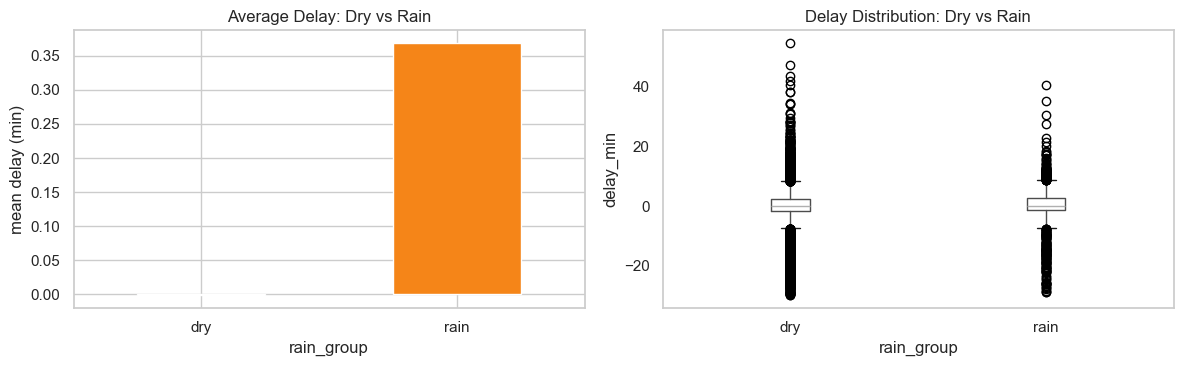

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('rain_group')['delay_min'].mean().plot(
    kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'], rot=0
)
axes[0].set_title('Average Delay: Dry vs Rain')
axes[0].set_xlabel('rain_group')
axes[0].set_ylabel('mean delay (min)')

df.boxplot(column='delay_min', by='rain_group', ax=axes[1], grid=False)
axes[1].set_title('Delay Distribution: Dry vs Rain')
axes[1].set_xlabel('rain_group')
axes[1].set_ylabel('delay_min')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 3. Data Preparation and Feature Sets

We compare two Decision Tree setups:
- `baseline`: time + route
- `full`: time + route + weather


In [77]:
target = 'delay_min'

time_num_features = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']
route_cat_features = ['route_short_name']
weather_num_features = ['temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']
weather_cat_features = ['rain_group']

features_baseline = time_num_features + route_cat_features
features_full = time_num_features + route_cat_features + weather_num_features + weather_cat_features

X = df[features_full].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['rain_group'],
)

split_distribution = pd.DataFrame({
    'full_data': df['rain_group'].value_counts(normalize=True).round(4),
    'train': X_train['rain_group'].value_counts(normalize=True).round(4),
    'test': X_test['rain_group'].value_counts(normalize=True).round(4),
})

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
split_distribution


Train size: (16248, 11)
Test size: (4063, 11)


,full_data,train,test
rain_group,,,
dry,0.8741,0.8741,0.874
rain,0.1259,0.1259,0.126


In [78]:
def build_preprocessor(feature_list):
    numeric_features = [
        col for col in feature_list
        if col in time_num_features + weather_num_features
    ]
    categorical_features = [
        col for col in feature_list
        if col in route_cat_features + weather_cat_features
    ]

    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ]
    )


def make_pipeline(feature_list):
    return Pipeline([
        ('preprocess', build_preprocessor(feature_list)),
        ('model', DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE)),
    ])


def evaluate_tree(label, feature_list):
    pipe = make_pipeline(feature_list)
    pipe.fit(X_train[feature_list], y_train)
    preds = pipe.predict(X_test[feature_list])

    return {
        'label': label,
        'pipe': pipe,
        'preds': preds,
        'r2': round(r2_score(y_test, preds), 4),
        'rmse': round(mean_squared_error(y_test, preds) ** 0.5, 4),
        'mae': round(mean_absolute_error(y_test, preds), 4),
    }


## 4. Main Models: Decision Tree Baseline vs Full


In [79]:
dt_baseline_run = evaluate_tree('Decision Tree baseline', features_baseline)
dt_full_run = evaluate_tree('Decision Tree full', features_full)

dt_results = pd.DataFrame([
    {k: v for k, v in dt_baseline_run.items() if k in ['label', 'r2', 'rmse', 'mae']},
    {k: v for k, v in dt_full_run.items() if k in ['label', 'r2', 'rmse', 'mae']},
])
dt_results


,label,r2,rmse,mae
0,Decision Tree baseline,0.2225,5.0892,3.4044
1,Decision Tree full,0.2186,5.1021,3.4023


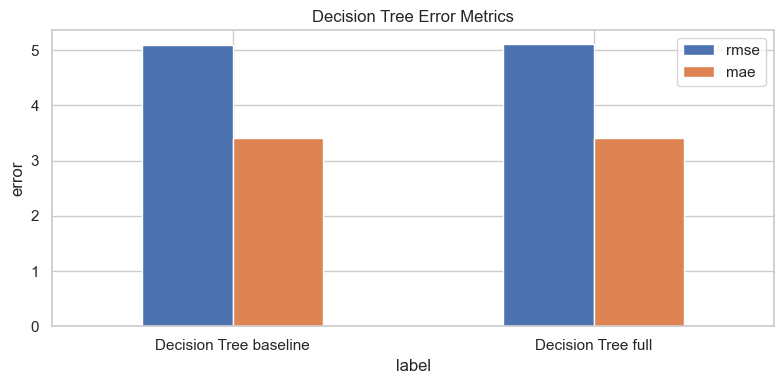

In [80]:
ax = dt_results.set_index('label')[['rmse', 'mae']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Decision Tree Error Metrics')
ax.set_ylabel('error')
plt.tight_layout()
plt.show()


## 5. Cross-Validation Check

Because a single Decision Tree can be unstable, we also run 5-fold cross-validation to see whether the main result is consistent across splits.


In [81]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipe = make_pipeline(features_baseline)
full_pipe = make_pipeline(features_full)

baseline_cv = cross_validate(
    baseline_pipe,
    X[features_baseline],
    y,
    cv=cv,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
    },
    n_jobs=-1,
)

full_cv = cross_validate(
    full_pipe,
    X[features_full],
    y,
    cv=cv,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
    },
    n_jobs=-1,
)

def summarize_cv(name, scores):
    return {
        'label': name,
        'cv_r2_mean': round(scores['test_r2'].mean(), 4),
        'cv_r2_std': round(scores['test_r2'].std(), 4),
        'cv_rmse_mean': round((-scores['test_rmse']).mean(), 4),
        'cv_rmse_std': round((-scores['test_rmse']).std(), 4),
        'cv_mae_mean': round((-scores['test_mae']).mean(), 4),
        'cv_mae_std': round((-scores['test_mae']).std(), 4),
    }

cv_results = pd.DataFrame([
    summarize_cv('Decision Tree baseline', baseline_cv),
    summarize_cv('Decision Tree full', full_cv),
])
cv_results


,label,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
0,Decision Tree baseline,0.2243,0.0112,4.9511,0.0793,3.3194,0.0385
1,Decision Tree full,0.2132,0.0118,4.9863,0.0819,3.3299,0.0391


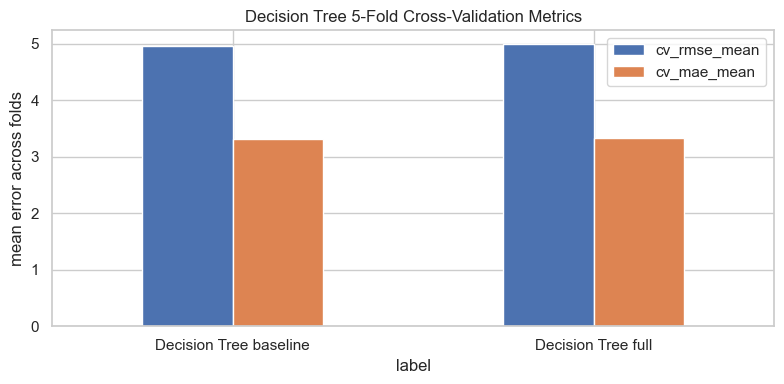

In [82]:
ax = cv_results.set_index('label')[['cv_rmse_mean', 'cv_mae_mean']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Decision Tree 5-Fold Cross-Validation Metrics')
ax.set_ylabel('mean error across folds')
plt.tight_layout()
plt.show()


## 6. Model Interpretation

Decision Trees are useful because we can inspect both grouped feature importance and the learned split structure.


In [83]:
dt_full_preprocessor = dt_full_run['pipe'].named_steps['preprocess']
dt_full_model = dt_full_run['pipe'].named_steps['model']
dt_feature_names = dt_full_preprocessor.get_feature_names_out()

dt_importance = pd.DataFrame({
    'feature': dt_feature_names,
    'importance': dt_full_model.feature_importances_,
}).sort_values('importance', ascending=False)

def feature_group(name):
    if 'route_short_name' in name:
        return 'route_related'
    if any(x in name for x in ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']):
        return 'time_related'
    return 'weather_related'

grouped_importance = dt_importance.copy()
grouped_importance['group'] = grouped_importance['feature'].apply(feature_group)
grouped_importance = grouped_importance.groupby('group', as_index=False)['importance'].sum().sort_values('importance', ascending=False)
grouped_importance


,group,importance
0,route_related,0.841435
1,time_related,0.105005
2,weather_related,0.053561


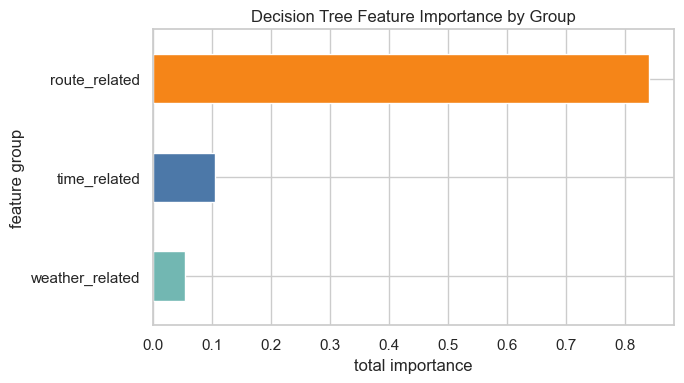

In [84]:
ax = grouped_importance.sort_values('importance').plot(
    kind='barh', x='group', y='importance', figsize=(7, 4), legend=False, color=['#72b7b2', '#4c78a8', '#f58518']
)
ax.set_title('Decision Tree Feature Importance by Group')
ax.set_xlabel('total importance')
ax.set_ylabel('feature group')
plt.tight_layout()
plt.show()


We do not emphasize individual routes here, because route was one-hot encoded into many separate columns. Instead, we group them into broader categories so the interpretation is cleaner for presentation: `route_related`, `time_related`, and `weather_related`.


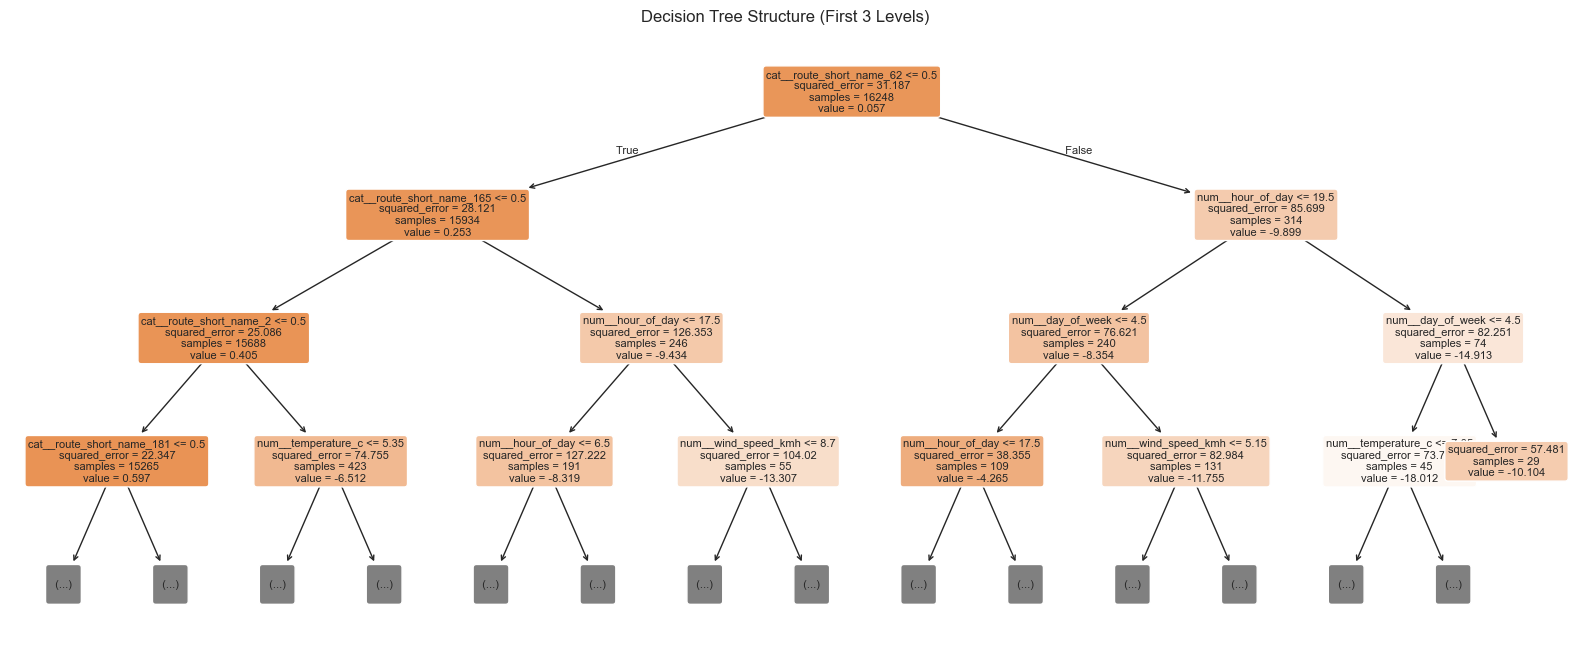

In [85]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_full_model,
    feature_names=dt_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title('Decision Tree Structure (First 3 Levels)')
plt.show()


## 7. Dry-vs-Rain Prediction Diagnostics


In [86]:
test_analysis = X_test.copy()
test_analysis['actual_delay'] = y_test.values
test_analysis['baseline_pred'] = dt_baseline_run['preds']
test_analysis['full_pred'] = dt_full_run['preds']

rain_prediction_summary = (
    test_analysis.groupby('rain_group')
      .agg(
          records=('actual_delay', 'count'),
          actual_mean_delay=('actual_delay', 'mean'),
          baseline_pred_mean=('baseline_pred', 'mean'),
          full_pred_mean=('full_pred', 'mean'),
      )
      .round(2)
)
rain_prediction_summary


,records,actual_mean_delay,baseline_pred_mean,full_pred_mean
rain_group,,,,
dry,3551,-0.06,0.01,-0.00
rain,512,0.42,0.15,0.19


In [87]:
peak_rain_prediction = (
    test_analysis.groupby(['is_peak_hour', 'rain_group'])
      .agg(
          records=('actual_delay', 'count'),
          actual_mean_delay=('actual_delay', 'mean'),
          full_pred_mean=('full_pred', 'mean'),
      )
      .round(2)
)
peak_rain_prediction.index = peak_rain_prediction.index.set_levels([
    ['non_rush', 'rush'] if level.name == 'is_peak_hour' else level
    for level in peak_rain_prediction.index.levels
])
peak_rain_prediction


records  actual_mean_delay  full_pred_mean
is_peak_hour rain_group                                            
non_rush     dry            2118               0.05            0.02
             rain            303               0.26            0.06
rush         dry            1433              -0.22           -0.05
             rain            209               0.65            0.38

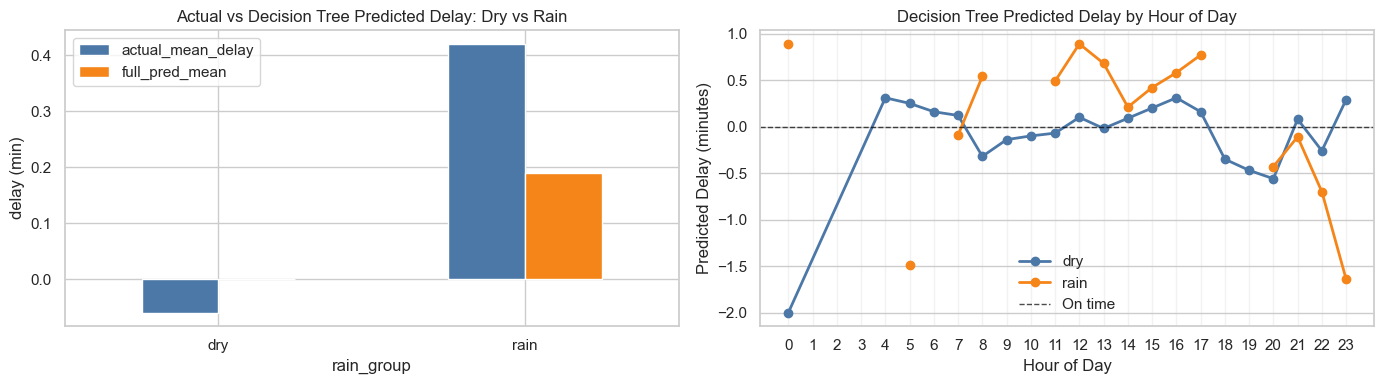

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rain_prediction_summary[['actual_mean_delay', 'full_pred_mean']].plot(
    kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'], rot=0
)
axes[0].set_title('Actual vs Decision Tree Predicted Delay: Dry vs Rain')
axes[0].set_ylabel('delay (min)')
axes[0].set_xlabel('rain_group')

hourly_pred = (
    test_analysis.groupby(['hour_of_day', 'rain_group'])['full_pred']
      .mean()
      .unstack()
      .round(2)
)

for col, color in [('dry', '#4c78a8'), ('rain', '#f58518')]:
    if col in hourly_pred.columns:
        axes[1].plot(hourly_pred.index, hourly_pred[col], marker='o', linewidth=2, color=color, label=col)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='On time')
axes[1].set_title('Decision Tree Predicted Delay by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Predicted Delay (minutes)')
axes[1].set_xticks(range(24))
axes[1].grid(True, axis='x', alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 8. Presentation Summary


### 8.1 Experiment flow: what we designed and why

We organized the Decision Tree experiment in this order:

1. **Problem setup**
   - Goal: predict `delay_min` and test whether rain helps explain bus delay.
   - Model choice: use a single Decision Tree as an interpretable baseline.

2. **Data preparation**
   - Use `model_input.csv`.
   - Keep the main weather comparison as `dry` vs `rain`, where `rain = rain_light + rain_moderate`.
   - Use a stratified train/test split so the dry-rain ratio stays consistent across train and test.

3. **Model design**
   - Train two versions:
     - `baseline`: time + route
     - `full`: time + route + weather
   - Set `max_depth = 8` and `min_samples_leaf = 20` to reduce overfitting and keep the tree interpretable.

4. **Evaluation design**
   - First evaluate with a single train/test split.
   - Then run 5-fold cross-validation to check whether the result is stable across different splits.

5. **Interpretation design**
   - Inspect grouped feature importance rather than listing many one-hot route columns.
   - Visualize the first few levels of the tree to see how the model splits the data.
   - Compare actual vs predicted delay for `dry` and `rain` to see whether the tree captures the rain effect directionally.


### 8.2 Problems we encountered and how we handled them

During the experiment, several issues became clear:

- **Rain vs dry is imbalanced**
  - There are many more dry records than rain records.
  - We handled this by using a stratified split so the train/test composition stayed consistent.

- **Route features become too detailed after one-hot encoding**
  - Individual `route_short_name_*` columns are not useful for presentation.
  - We grouped them into broader categories such as `route_related`, `time_related`, and `weather_related` for interpretation.

- **A single Decision Tree can be unstable**
  - One split can be misleading.
  - We added 5-fold cross-validation to test whether the same conclusion holds across folds.

- **The model may capture direction but not magnitude**
  - In the dry-vs-rain comparison, the predicted rain delay is noticeably smaller than the observed rain delay.
  - We interpret this as underestimation of the rain effect rather than pretending the model fits perfectly.


### 8.3 What we tested, what results we got, and what to say

Following the experimental order, the main findings are:

1. **Descriptive analysis**
   - Rain is associated with slightly higher average delay than dry conditions.
   - This means the rain effect is visible in the raw data directionally.

2. **Single train/test split**
   - The Decision Tree baseline performs slightly better than the full weather-aware Decision Tree.
   - So adding weather features does not improve prediction in this setup.

3. **5-fold cross-validation**
   - CV confirms the same pattern:
     - `Decision Tree baseline`: `cv_r2_mean = 0.2243`, `cv_rmse_mean = 4.9511`, `cv_mae_mean = 3.3194`
     - `Decision Tree full`: `cv_r2_mean = 0.2132`, `cv_rmse_mean = 4.9863`, `cv_mae_mean = 3.3299`
   - The standard deviations are small, so this is not just a one-split accident.

4. **Interpretation**
   - Grouped feature importance shows that route-related and time-related information are stronger than weather-related information.
   - The tree structure is still useful because it lets us inspect the learned decision rules directly.

5. **Dry vs rain prediction check**
   - The model predictions are consistent with the same directional pattern seen in the descriptive analysis: predicted delay is higher under rain than under dry conditions.

Final conclusion:
- The Decision Tree is useful as an **interpretable baseline**.
- Rain is associated with higher delay in the data, but route and time features are stronger drivers of bus delay than weather in this dataset.
- Adding weather features does not improve Decision Tree performance, either in a single split or in 5-fold cross-validation.

What to say in the presentation:
- "I used a Decision Tree as an interpretable baseline for bus delay prediction."

- "I compared a baseline model using time and route features with a full model that also includes weather features."

- "To reduce overfitting, I limited the tree depth to 8 and required at least 20 samples per leaf."

- "I first evaluated the model with a train/test split, and then used 5-fold cross-validation to check stability."

- "Both evaluations showed the same pattern: the baseline model performs slightly better than the weather-aware model."

- "The descriptive analysis shows that rain is associated with higher average delay, and the model predictions are consistent with that same directional pattern."

- "Grouped feature importance shows that route and time features are stronger predictors than weather features in this dataset."
